In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ercenttannius","key":"84f8198c294490fd45ab7d1d088e8ad5"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API siap!")

✅ Kaggle API siap!


In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
print("✅ Download selesai!")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.03G/2.04G [00:53<00:00, 48.0MB/s]
100% 2.04G/2.04G [00:54<00:00, 40.3MB/s]
✅ Download selesai!


In [ ]:
!unzip plantvillage-dataset.zip -d /content/dataset
print("✅ Extract selesai!")

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e37e8ad-3944-4e11-bc10-dd82616274d7___YLCV_NREC 2915_final_masked.jpg  
  inflating: /content/dataset/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e382244-fb3a-4caa-af71-05fff25f1c27___UF.GRC_YLCV_Lab 03397_final_masked.jpg  
  inflating: /content/dataset/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e3b9886-ce13-49d5-8f80-ccf4e5ddbeac___YLCV_GCREC 5479_final_masked.jpg  
  inflating: /content/dataset/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e615038-7a87-446a-a2cd-f76c5c75b6dd___YLCV_GCREC 5144_final_masked.jpg  
  inflating: /content/dataset/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e6938d9-1ab0-4728-993c-1069b66ce73b___UF.GRC_YLCV_Lab 02727_final_masked.jpg  
  inflating: /content/dataset/plantvillage dataset/segmented/Tomato_

In [ ]:
import os

dataset_path = '/content/dataset'
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:3]:
            print(f"{indent}  {f}")

dataset/
  plantvillage dataset/
    grayscale/
      Strawberry___Leaf_scorch/
      Potato___Early_blight/
      Corn_(maize)___healthy/
      Pepper,_bell___Bacterial_spot/
      Raspberry___healthy/
      Peach___healthy/
      Tomato___Target_Spot/
      Grape___healthy/
      Squash___Powdery_mildew/
      Corn_(maize)___Northern_Leaf_Blight/
      Tomato___Tomato_mosaic_virus/
      Apple___Apple_scab/
      Tomato___Spider_mites Two-spotted_spider_mite/
      Tomato___Leaf_Mold/
      Apple___healthy/
      Strawberry___healthy/
      Potato___healthy/
      Tomato___Late_blight/
      Orange___Haunglongbing_(Citrus_greening)/
      Cherry_(including_sour)___Powdery_mildew/
      Tomato___healthy/
      Blueberry___healthy/
      Tomato___Bacterial_spot/
      Peach___Bacterial_spot/
      Corn_(maize)___Common_rust_/
      Apple___Black_rot/
      Pepper,_bell___healthy/
      Potato___Late_blight/
      Grape___Leaf_blight_(Isariopsis_Leaf_Spot)/
      Tomato___Septoria_leaf_

In [ ]:
!pip install timm -q

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
from tqdm import tqdm

In [ ]:
path = "/content/dataset" # change path
BATCH_SIZE = 32
EPOCHS = 15
LR = 0.0001
IMG_SIZE = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
import os
from torchvision import datasets
from torch.utils.data import DataLoader

# The path based on your specific 'color' subdirectory find
data_root = "/content/dataset/plantvillage dataset/color"
# Verify the contents—you should see folder names like 'Apple___Apple_scab', etc.
print("Actual classes found:", os.listdir(data_root))
#transormasi -> ini yang ada dimateri compvis
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# Load the dataset
# Note: If this folder contains the classes directly (no 'train'/'val' split),
# you'll need to manually split the dataset.
full_dataset = datasets.ImageFolder(root=data_root, transform=train_transforms)

# Example: 80/20 Split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total images: {len(full_dataset)}")

Actual classes found: ['Strawberry___Leaf_scorch', 'Potato___Early_blight', 'Corn_(maize)___healthy', 'Pepper,_bell___Bacterial_spot', 'Raspberry___healthy', 'Peach___healthy', 'Tomato___Target_Spot', 'Grape___healthy', 'Squash___Powdery_mildew', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Tomato_mosaic_virus', 'Apple___Apple_scab', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Leaf_Mold', 'Apple___healthy', 'Strawberry___healthy', 'Potato___healthy', 'Tomato___Late_blight', 'Orange___Haunglongbing_(Citrus_greening)', 'Cherry_(including_sour)___Powdery_mildew', 'Tomato___healthy', 'Blueberry___healthy', 'Tomato___Bacterial_spot', 'Peach___Bacterial_spot', 'Corn_(maize)___Common_rust_', 'Apple___Black_rot', 'Pepper,_bell___healthy', 'Potato___Late_blight', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Tomato___Septoria_leaf_spot', 'Cherry_(including_sour)___healthy', 'Tomato___Early_blight', 'Grape___Black_rot', 'Apple___Cedar_apple_rust', 'Soybean___healthy', 'Corn_(

In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    break

/content/dataset


In [ ]:
!ls /content/dataset

'plantvillage dataset'


In [ ]:
!ls "/content/dataset/plantvillage dataset"

color  grayscale  segmented


In [ ]:
from torch.utils.data import random_split

DATA_DIR = "/content/dataset/plantvillage dataset/color"

full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)

# 80-20 split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply validation transform separately
val_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

num_classes = len(full_dataset.classes)
print("Classes:", full_dataset.classes)

Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___

In [ ]:
model = timm.create_model("efficientnet_b0", pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [ ]:
def train_one_epoch():
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100. * correct / total
    return running_loss/len(train_loader), accuracy

In [ ]:
def validate():
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100. * correct / total
    return running_loss/len(val_loader), accuracy, all_preds, all_labels

In [ ]:
best_acc = 0
patience = 3
trigger = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc, preds, labels = validate()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "efficientnet_plant_best.pth")
        print("✅ Model Saved!")
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            print("⛔ Early Stopping Triggered")
            break


Epoch 1/15


100%|██████████| 1358/1358 [05:12<00:00,  4.35it/s]


Train Loss: 0.3159 | Train Acc: 93.28%
Val Loss: 0.0280 | Val Acc: 99.27%
✅ Model Saved!

Epoch 2/15


100%|██████████| 1358/1358 [05:09<00:00,  4.39it/s]


Train Loss: 0.0273 | Train Acc: 99.18%
Val Loss: 0.0170 | Val Acc: 99.54%
✅ Model Saved!

Epoch 3/15


...

Train Loss: 0.0133 | Train Acc: 99.62%
Val Loss: 0.0136 | Val Acc: 99.57%

Epoch 5/15


100%|██████████| 1358/1358 [05:15<00:00,  4.31it/s]


Train Loss: 0.0100 | Train Acc: 99.72%
Val Loss: 0.0190 | Val Acc: 99.49%

Epoch 6/15


100%|██████████| 1358/1358 [05:09<00:00,  4.39it/s]


Train Loss: 0.0066 | Train Acc: 99.79%
Val Loss: 0.0144 | Val Acc: 99.52%
⛔ Early Stopping Triggered


In [ ]:
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=full_dataset.classes))
print("Training Complete 🚀")


Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00       119
                                 Apple___Black_rot       1.00      1.00      1.00       116
                          Apple___Cedar_apple_rust       1.00      0.98      0.99        47
                                   Apple___healthy       1.00      1.00      1.00       350
                               Blueberry___healthy       1.00      1.00      1.00       282
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       185
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       163
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.88      0.93      0.91       113
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       223
               Corn_(maize)___Northern_Leaf_Blight     

In [ ]:
import os

# Lihat isi folder dulu
folder = "/content/dataset/plantvillage dataset/color/Apple___Apple_scab"
print(os.listdir(folder)[:5])

['276ed34e-9987-4b38-b83b-8626504fc204___FREC_Scab 3050.JPG', '34c37353-8429-499e-bd38-ac7501f79e90___FREC_Scab 3501.JPG', '8455ff58-ba10-44ee-abfc-0055cf6f0449___FREC_Scab 3135.JPG', '444c4ed0-3bee-4059-870a-a15a00f0e37e___FREC_Scab 3067.JPG', '892da302-54b8-43a1-960d-055f5eb3f0a1___FREC_Scab 3019.JPG']


In [ ]:
folder = "/content/dataset/plantvillage dataset/color/Apple___Apple_scab"
filename = os.listdir(folder)[0]
image_path = os.path.join(folder, filename)

print("Image path:", image_path)

Image path: /content/dataset/plantvillage dataset/color/Apple___Apple_scab/276ed34e-9987-4b38-b83b-8626504fc204___FREC_Scab 3050.JPG


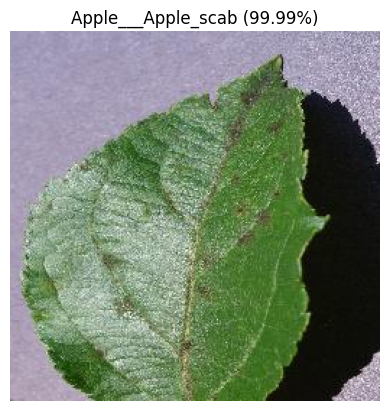

Prediction: Apple___Apple_scab
Confidence: 99.99%


In [ ]:
import torch
import timm
from torchvision import transforms
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Use classes directly from dataset
class_names = full_dataset.classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = timm.create_model("efficientnet_b0", pretrained=False)
model.classifier = nn.Linear(model.classifier.in_features, len(class_names))
model.load_state_dict(torch.load("efficientnet_plant_best.pth", map_location=device))
model.to(device)
model.eval()

# CHANGE THIS PATH
image_path = "/content/dataset/plantvillage dataset/color/Apple___Apple_scab/276ed34e-9987-4b38-b83b-8626504fc204___FREC_Scab 3050.JPG"
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    probs = F.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probs, 1)

predicted_class = class_names[predicted.item()]
confidence_score = confidence.item() * 100

plt.imshow(image)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence_score:.2f}%)")
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", f"{confidence_score:.2f}%")

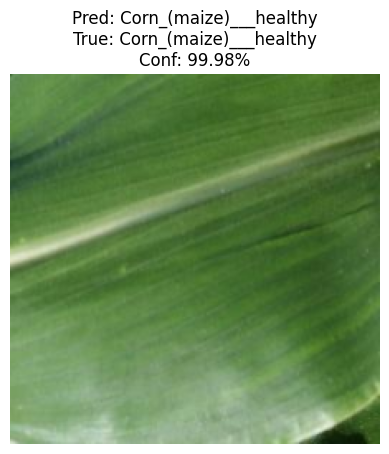

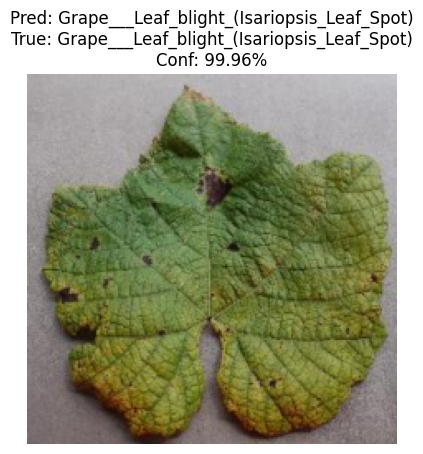

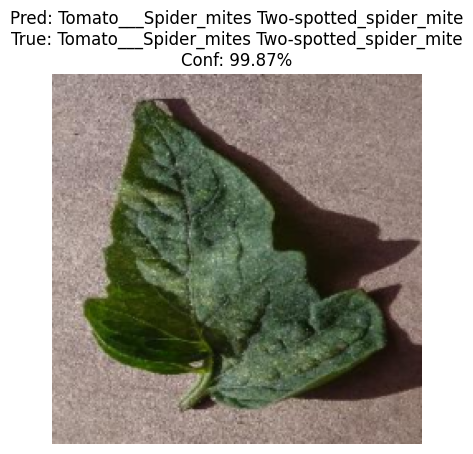

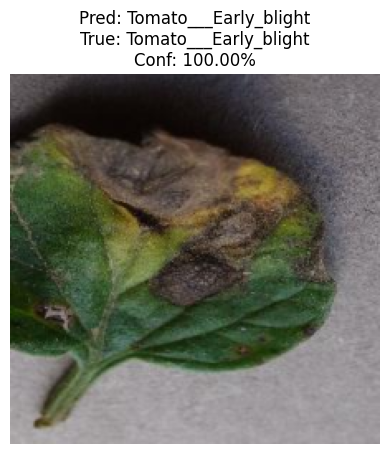

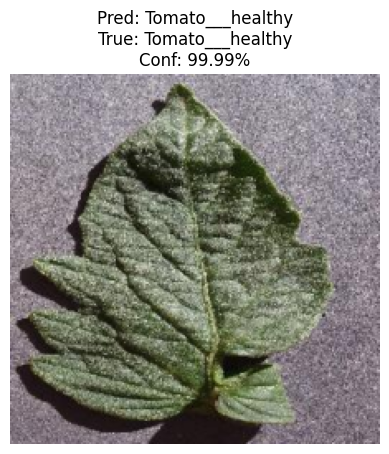

In [ ]:
import random
import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()

for i in range(5):
    img, label = val_dataset[random.randint(0, len(val_dataset)-1)]
    img_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    plt.imshow(img.permute(1,2,0))
    plt.axis("off")
    plt.title(f"Pred: {class_names[pred.item()]}\nTrue: {class_names[label]}\nConf: {conf.item()*100:.2f}%")
    plt.show()

In [ ]:
import json

class_names = full_dataset.classes

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("class_names.json saved successfully!")

class_names.json saved successfully!


In [ ]:
from google.colab import files
files.download("/content/class_names.json")
files.download("/content/efficientnet_plant_best.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>